## prepare wHO mutation catalog

In [ ]:
import os
import re
import pandas as pd
from Bio import SeqIO


In [ ]:

# === STEP 1: Parse and filter WHO catalog ===
def load_and_filter_catalog(file_path, target_genes):
    pattern = re.compile(r'(?P<gene>[A-Za-z0-9]+)_p\.(?P<ref>[A-Z][a-z]{2})(?P<pos>\d+)(?P<alt>[A-Z][a-z]{2})')
    aa3_to_1 = {
        'Ala': 'A', 'Arg': 'R', 'Asn': 'N', 'Asp': 'D', 'Cys': 'C', 'Glu': 'E',
        'Gln': 'Q', 'Gly': 'G', 'His': 'H', 'Ile': 'I', 'Leu': 'L', 'Lys': 'K',
        'Met': 'M', 'Phe': 'F', 'Pro': 'P', 'Ser': 'S', 'Thr': 'T', 'Trp': 'W',
        'Tyr': 'Y', 'Val': 'V', 'Sec': 'U', 'Pyl': 'O', 'Asx': 'B', 'Glx': 'Z',
        'Xaa': 'X', 'Ter': '*'
    }

    df = pd.read_excel(
        file_path,
        sheet_name="Catalogue_master_file",
        header=2,
        usecols=[
            "drug", "gene", "variant", "effect", "Present_R", "Present_S", "FINAL CONFIDENCE GRADING"
        ]
    )
    df.columns = df.columns.str.strip()
    df = df[df["variant"].astype(str).str.match(pattern)].copy()
    df["gene_from_variant"] = df["variant"].str.extract(r'^([A-Za-z0-9]+)_p\.')[0].str.lower()
    df = df[df["gene_from_variant"].isin(g.lower() for g in target_genes)]

    df[["aa_ref_3", "aa_pos", "aa_alt_3"]] = df["variant"].str.extract(
        r'_p\.(?P<aa_ref_3>[A-Z][a-z]{2})(?P<aa_pos>\d+)(?P<aa_alt_3>[A-Z][a-z]{2})'
    )
    df["aa_ref"] = df["aa_ref_3"].map(aa3_to_1)
    df["aa_change"] = df["aa_alt_3"].map(aa3_to_1)
    df["aa_pos"] = df["aa_pos"].astype(int)
    df["one_letter_mutation"] = "p." + df["aa_ref"] + df["aa_pos"].astype(str) + df["aa_change"]

    final_cols = [
        "drug", "gene", "variant", "effect", "Present_R", "Present_S", "FINAL CONFIDENCE GRADING",
        "one_letter_mutation", "aa_pos", "aa_change", "aa_ref"
    ]
    df = df[final_cols].rename(columns={"FINAL CONFIDENCE GRADING": "confidence"})
    return df


# === STEP 2: Parse protein FASTA ===
def parse_protein_fasta(file_path):
    protein_sequences = {}
    for record in SeqIO.parse(file_path, "fasta"):
        protein_sequences[record.id] = str(record.seq)
    return protein_sequences


# === STEP 3: Variant intersection logic ===
def check_variants_in_proteins(protein_sequences, variants):
    variants = variants.drop_duplicates(subset=['aa_pos', 'aa_ref', 'aa_change']).copy()
    intersection_flags = []

    for idx, row in variants.iterrows():
        aa_pos = row['aa_pos']
        aa_ref = row['aa_ref']
        found = False
        for seq in protein_sequences.values():
            if aa_pos <= len(seq) and seq[aa_pos - 1] == aa_ref:
                found = True
                break
        intersection_flags.append(found)

    variants["intersectional"] = intersection_flags
    return variants


# === STEP 4: Integration runner ===
def run_intersection_pipeline(catalog_path, fasta_dir, output_path, genes):
    catalog_df = load_and_filter_catalog(catalog_path, genes)
    all_variants = []

    for gene in genes:
        fasta_file = os.path.join(fasta_dir, f"all_sequences_{gene}_aa.fasta")
        if os.path.exists(fasta_file):
            print(f"Processing: {gene}")
            seqs = parse_protein_fasta(fasta_file)
            gene_variants = catalog_df[catalog_df["gene"].str.lower() == gene.lower()].copy()
            gene_variants = check_variants_in_proteins(seqs, gene_variants)
            all_variants.append(gene_variants)
        else:
            print(f"FASTA missing for: {gene}")

    merged = pd.concat(all_variants)
    merged.to_csv(output_path, index=False)
    print(f"Saved output to: {output_path}")

    # Print summary
    summary = merged.groupby("gene")["intersectional"].agg(["sum", "count"])
    summary["recall"] = summary["sum"] / summary["count"]
    return summary

In [ ]:
# RUN
CATALOG_PATH = "./data/catalog/WHO-UCN-TB-2023.7-eng.xlsx"
FASTA_DIR = "./data/aa_fasta"
OUTPUT_PATH = "./data/filtered_variants_output.csv"
GENES =['rpoB','rpsL','tlyA','pncA','eis','gid','katG','inhA','embA','embB', 'embC','gyrB', 'gyrA', 'ethA', 'ethR']

summary_df = run_intersection_pipeline(CATALOG_PATH, FASTA_DIR, OUTPUT_PATH, GENES)

##  precision-recall

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
## load all four files

# Load the four PR summary CSVs again due to kernel reset
esm_path = Path("residue_importance/esm_rf_k10.csv")
refalt_path = Path("residue_importance/refalt_k10.csv")
cnn_path = Path("residue_importance/cnn_k10.csv")
transformer_path = Path("residue_importance/transformer_k10.csv")

# Load and annotate ESM-classical
esm_df = pd.read_csv(esm_path)
print(esm_df)
esm_df["model"] = "random_forest"
esm_df["model_type"] = "esm_classical"

# Load and annotate ref-alt encoding models
refalt_df = pd.read_csv(refalt_path)

refalt_df["model_type"] = "ref_alt"

# Load and annotate CNN results
cnn_df = pd.read_csv(cnn_path)
cnn_df["model"] = "cnn"
cnn_df["model_type"] = "raw_dl"

# Load and annotate Transformer results
tr_df = pd.read_csv(transformer_path)
tr_df["model"] = "transformer"
tr_df["model_type"] = "raw_dl"


# Harmonize all column structures
standard_cols = ["gene","model", "k", "TP", "precision", "recall", "F1", "identified_variants", "model_type"]

def standardize(df, default_k=100):
    for col in standard_cols:
        if col not in df.columns:
            if col == "k":
                df[col] = default_k
            else:
                df[col] = None
    return df[standard_cols]

esm_df = standardize(esm_df)
refalt_df = standardize(refalt_df)
cnn_df = standardize(cnn_df)
tr_df = standardize(tr_df)

# Combine all
combined_df = pd.concat([refalt_df, esm_df, cnn_df, tr_df], ignore_index=True)

# Save for downstream analysis
combined_df.to_csv("residue_importance/combined_pr_k10.csv", index=False)



    gene  Total_Resistance_Positions   k  TP  precision    recall        F1  \
0   rpoB                          26  10   0        0.0  0.000000  0.000000   
1   rpsL                           2  10   0        0.0  0.000000  0.000000   
2   tlyA                           2  10   1        0.1  0.500000  0.166667   
3   pncA                          95  10   2        0.2  0.021053  0.038095   
4    eis                           0  10   0        0.0  0.000000  0.000000   
5    gid                           8  10   0        0.0  0.000000  0.000000   
6   katG                           2  10   0        0.0  0.000000  0.000000   
7   inhA                           1  10   0        0.0  0.000000  0.000000   
8   embB                           6  10   1        0.1  0.166667  0.125000   
9   gyrB                           5  10   0        0.0  0.000000  0.000000   
10  gyrA                           5  10   0        0.0  0.000000  0.000000   
11  ethA                           9  10   0        

In [2]:
combined_df = pd.read_csv("residue_importance/drug_level_summary.csv")
# Strip whitespace and tab characters from model names
combined_df["model"] = combined_df["model"].str.strip()


In [3]:
# Clean LaTeX-sensitive characters
combined_df["identified_variants"] = combined_df["identified_variants"].fillna("").apply(lambda x: x.replace("_", r"\_").replace(",", ", "))

# Round float columns
for col in ["precision", "recall", "F1"]:
    combined_df[col] = pd.to_numeric(combined_df[col], errors="coerce").round(2)

# Build LaTeX table rows
latex_rows = []
for _, row in combined_df.iterrows():
    latex_row = f"{row['drug']} & {row['model']} & {int(row['k'])} & {int(row['TP'])} & {row['precision']} & {row['recall']} & {row['F1']} & {row['identified_variants']} & {row['model_type']} \\\\"
    latex_rows.append(latex_row)

# Build the full LaTeX table with landscape mode
latex_table = r"""
\begin{landscape}
\begin{table}[ht]
\centering
\footnotesize
\setlength{\tabcolsep}{4pt}
\caption{Variant-level interpretability metrics (precision, recall, F1-score) and discovered variants at top-10 residues for each model.}
\label{tab:variant_discovery_all}
\begin{tabular}{l l c c c c c p{8.5cm} l}
\toprule
\textbf{Drug} & \textbf{Model} & \textbf{k} & \textbf{TP} & \textbf{Prec.} & \textbf{Recall} & \textbf{F1} & \textbf{Identified Variants} & \textbf{Type} \\
\midrule
""" + "\n".join(latex_rows) + r"""
\bottomrule
\end{tabular}
\end{table}
\end{landscape}
"""

# Output LaTeX code
latex_table[:3000]  # show first portion for verification


'\n\\begin{landscape}\n\\begin{table}[ht]\n\\centering\n\\footnotesize\n\\setlength{\\tabcolsep}{4pt}\n\\caption{Variant-level interpretability metrics (precision, recall, F1-score) and discovered variants at top-10 residues for each model.}\n\\label{tab:variant_discovery_all}\n\\begin{tabular}{l l c c c c c p{8.5cm} l}\n\\toprule\n\\textbf{Drug} & \\textbf{Model} & \\textbf{k} & \\textbf{TP} & \\textbf{Prec.} & \\textbf{Recall} & \\textbf{F1} & \\textbf{Identified Variants} & \\textbf{Type} \\\\\n\\midrule\nRifampicin & lasso & 10 & 8 & 0.8 & 0.31 & 0.44 & rpoB\\_p.Asp435Ala,  rpoB\\_p.Gln432Asn,  rpoB\\_p.His445Arg,  rpoB\\_p.Ile491Phe,  rpoB\\_p.Leu430Arg,  rpoB\\_p.Leu452Met,  rpoB\\_p.Ser450Ala,  rpoB\\_p.Val170Phe & ref_alt \\\\\nRifampicin & ridge & 10 & 7 & 0.7 & 0.27 & 0.39 & rpoB\\_p.Asp435Ala,  rpoB\\_p.Gln432Asn,  rpoB\\_p.His445Arg,  rpoB\\_p.Leu452Met,  rpoB\\_p.Ser441Ala,  rpoB\\_p.Ser450Ala,  rpoB\\_p.Val170Phe & ref_alt \\\\\nRifampicin & logreg & 10 & 7 & 0.7 & 0.27 &

In [5]:
# Compute mean and std per model
mean_std_summary = combined_df.groupby("model")[["precision", "recall", "F1"]].agg(["mean", "std"]).reset_index()

# Find best performing model per gene (based on F1-score)
best_model_per_drug = combined_df.loc[combined_df.groupby("drug")["F1"].idxmax()][["drug", "model", "F1"]]

# Count how often each model is best across genes
best_model_counts = best_model_per_drug["model"].value_counts().reset_index()
best_model_counts.columns = ["model", "num_drugs_best"]


In [6]:
mean_std_summary

model precision              recall                  F1          
                      mean       std      mean       std      mean       std
0            cnn  0.066667  0.100000  0.055556  0.131825  0.046667  0.091515
1          lasso  0.322222  0.327024  0.385556  0.368039  0.255556  0.242441
2         logreg  0.344444  0.334892  0.431111  0.371969  0.272222  0.203579
3  random_forest  0.044444  0.072648  0.076667  0.168226  0.036667  0.064031
4          ridge  0.288889  0.235555  0.401111  0.339207  0.246667  0.162558
5    transformer  0.144444  0.235112  0.108889  0.172731  0.081111  0.114831

In [7]:
best_model_per_drug

,drug,model,F1
29,Capreomycin,random_forest,0.17
15,Ethambutol,lasso,0.75
25,Ethionamide,ridge,0.21
13,Isoniazid,ridge,0.26
22,Levofloxacin,ridge,0.53
43,Moxifloxacin,cnn,0.27
11,Pyrazinamide,logreg,0.19
0,Rifampicin,lasso,0.44
3,Streptomycin,lasso,0.28


In [8]:
best_model_counts

,model,num_drugs_best
0,lasso,3
1,ridge,3
2,random_forest,1
3,cnn,1
4,logreg,1


In [9]:

# Compute mean precision and recall per model
summary_stats = combined_df.groupby("model")[["precision", "recall"]].mean().reset_index()
summary_stats["precision"] = summary_stats["precision"].round(3)
summary_stats["recall"] = summary_stats["recall"].round(3)

# Determine the best model based on F1
combined_df["F1"] = (2 * combined_df["precision"] * combined_df["recall"]) / (combined_df["precision"] + combined_df["recall"] + 1e-8)
best_model_stats = combined_df.groupby("model")["F1"].mean().reset_index().sort_values("F1", ascending=False)
best_model_stats

# Compute mean and std of precision/recall per model
summary_stats = combined_df.groupby("model")[["precision", "recall", "F1"]].agg(["mean", "std"]).reset_index()
summary_stats.columns = ["model", "precision_mean", "precision_std", "recall_mean", "recall_std", "f1_mean", "f1_std"]

# Best-performing model per gene
best_f1 = combined_df.loc[combined_df.groupby("drug")["F1"].idxmax()][["drug", "model", "F1"]]

# Count of zero precision per gene per model
zero_precision = combined_df[combined_df["precision"] == 0].groupby("drug").size().reset_index(name="zero_precision_model_count")

# Count of non-zero recall per model
nonzero_recall = combined_df[combined_df["recall"] > 0].groupby("model").size().reset_index(name="num_drugs_with_recall")

# Show results
print("Summary Stats:\n", summary_stats)
print("\nBest Model per drug:\n", best_f1)
print("\nHard drug (all zero precision):\n", zero_precision[zero_precision["zero_precision_model_count"] == combined_df["model"].nunique()])
print("\nRecall Comparison:\n", nonzero_recall)

Summary Stats:
            model  precision_mean  precision_std  recall_mean  recall_std  \
0            cnn        0.066667       0.100000     0.055556    0.131825   
1          lasso        0.322222       0.327024     0.385556    0.368039   
2         logreg        0.344444       0.334892     0.431111    0.371969   
3  random_forest        0.044444       0.072648     0.076667    0.168226   
4          ridge        0.288889       0.235555     0.401111    0.339207   
5    transformer        0.144444       0.235112     0.108889    0.172731   

    f1_mean    f1_std  
0  0.046368  0.090929  
1  0.258441  0.243872  
2  0.275652  0.204321  
3  0.036551  0.064162  
4  0.249718  0.163293  
5  0.080382  0.115241  

Best Model per drug:
             drug          model        F1
29   Capreomycin  random_forest  0.166667
15    Ethambutol          lasso  0.750000
25   Ethionamide          ridge  0.209524
13     Isoniazid          ridge  0.260870
22  Levofloxacin          ridge  0.533333
43  Moxi

In [10]:
summary_stats

,model,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,cnn,0.066667,0.100000,0.055556,0.131825,0.046368,0.090929
1,lasso,0.322222,0.327024,0.385556,0.368039,0.258441,0.243872
2,logreg,0.344444,0.334892,0.431111,0.371969,0.275652,0.204321
3,random_forest,0.044444,0.072648,0.076667,0.168226,0.036551,0.064162
4,ridge,0.288889,0.235555,0.401111,0.339207,0.249718,0.163293
5,transformer,0.144444,0.235112,0.108889,0.172731,0.080382,0.115241


/work/pi_annagreen_umass_edu/mahbuba/protein/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/work/pi_annagreen_umass_edu/mahbuba/protein/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/work/pi_annagreen_umass_edu/mahbuba/protein/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_dat

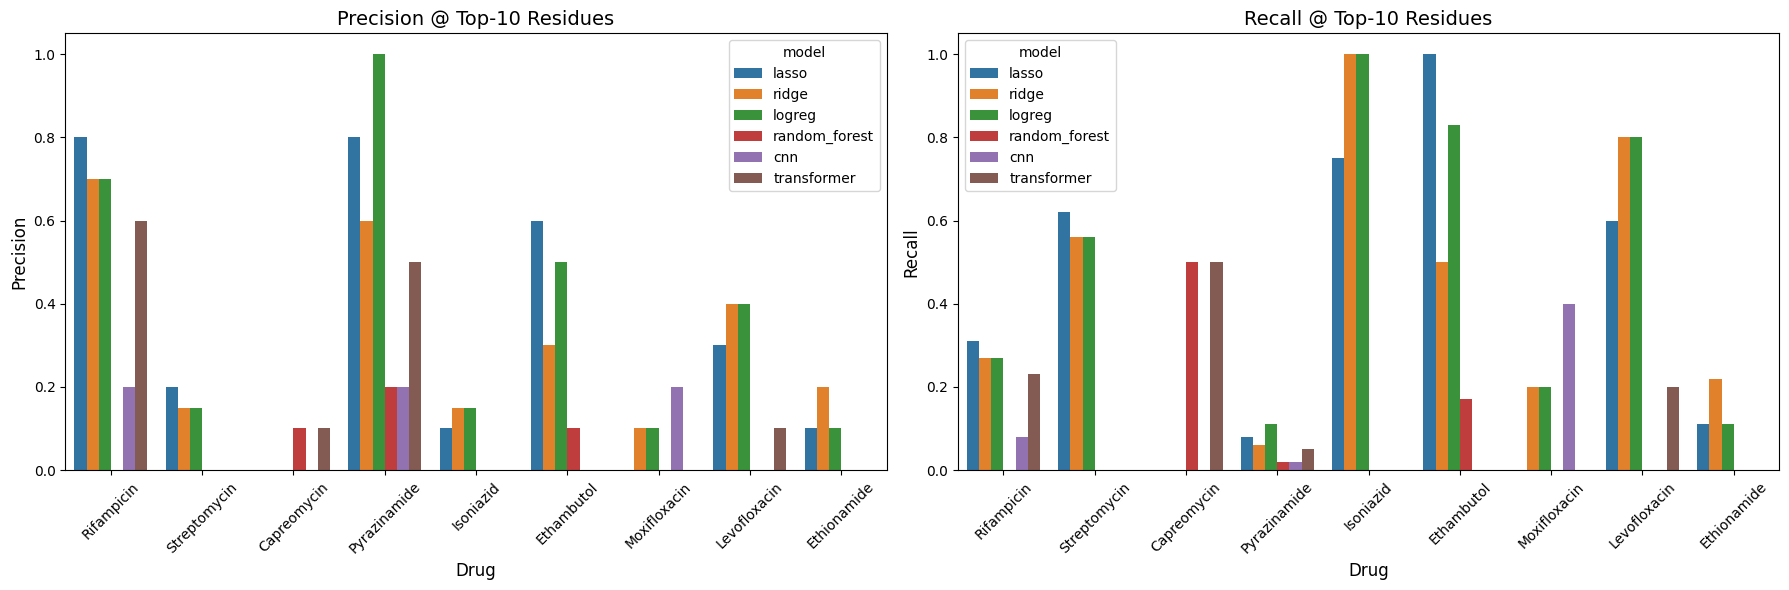

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt


# Filter to only the desired top-k
k_values = [10]
metrics = ['precision', 'recall']
models = combined_df['model'].unique()

# Create side-by-side plots (1 row, 2 columns)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

for j, metric in enumerate(metrics):
    ax = axs[j]
    data = combined_df[(combined_df['k'] == 10)]
    
    sns.barplot(data=data, x='drug', y=metric, hue='model', ax=ax)
    ax.set_title(f'{metric.capitalize()} @ Top-10 Residues', fontsize=14)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Drug', fontsize=12)
    ax.set_ylabel(metric.capitalize(), fontsize=12)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("residue_importance/precision_recall_top10.png")
plt.show()


In [12]:
esm_path = Path("residue_importance/esm_rf_k10.csv")
esm_df = pd.read_csv(esm_path)
esm_df

,gene,Total_Resistance_Positions,k,TP,precision,recall,F1,identified_variants
0,rpoB,26,10,0,0.0,0.000000,0.000000,NaN
1,rpsL,2,10,0,0.0,0.000000,0.000000,NaN
2,tlyA,2,10,1,0.1,0.500000,0.166667,tlyA_p.Asn236Lys
3,pncA,95,10,2,0.2,0.021053,0.038095,"pncA_p.Gly78Asp, pncA_p.Gly78Ser, pncA_p.Gly78..."
4,eis,0,10,0,0.0,0.000000,0.000000,NaN
5,gid,8,10,0,0.0,0.000000,0.000000,NaN
6,katG,2,10,0,0.0,0.000000,0.000000,NaN
7,inhA,1,10,0,0.0,0.000000,0.000000,NaN
8,embB,6,10,1,0.1,0.166667,0.125000,"embB_p.Gly406Ala, embB_p.Gly406Asp, embB_p.Gly..."
9,gyrB,5,10,0,0.0,0.000000,0.000000,NaN


In [13]:
top_per_gene = combined_df.sort_values("F1", ascending=False).groupby("drug").first().reset_index()
top10_diverse = top_per_gene.sort_values("F1", ascending=False).head(15)
top10_diverse

,drug,model,k,TP,precision,recall,F1,identified_variants,model_type
1,Ethambutol,lasso,10,6,0.60,1.00,0.750000,"embB\_p.Asp328Tyr, embB\_p.Asp354Ala, embB\_...",ref_alt
4,Levofloxacin,logreg,10,4,0.40,0.80,0.533333,"gyrA\_p.Ala90Val, gyrA\_p.Asp94Ala, gyrA\_p....",ref_alt
7,Rifampicin,lasso,10,8,0.80,0.31,0.446847,"rpoB\_p.Asp435Ala, rpoB\_p.Gln432Asn, rpoB\_...",ref_alt
8,Streptomycin,lasso,10,4,0.20,0.62,0.302439,"rpsL\_p.Lys43Arg, rpsL\_p.Lys88Arg, gid\_p.A...",\tref_alt
5,Moxifloxacin,cnn,10,2,0.20,0.40,0.266667,"gyrA\_p.Ala90Val, gyrA\_p.Ser91Pro",raw_dl
3,Isoniazid,ridge,10,3,0.15,1.00,0.260870,"katG\_p.Ser315Arg, katG\_p.Trp328Leu",ref_alt
2,Ethionamide,ridge,10,2,0.20,0.22,0.209524,"ethA\_p.Cys403Tyr, ethA\_p.Val202Gly",ref_alt
6,Pyrazinamide,logreg,10,10,1.00,0.11,0.198198,"pncA\_p.Cys14Arg, pncA\_p.Gln10Arg, pncA\_p....",ref_alt
0,Capreomycin,transformer,10,1,0.10,0.50,0.166667,tlyA\_p.Gly232Asp,raw_dl


In [14]:
#F1 ≥ Threshold Table (e.g., ≥ 0.4)
strong_rows = combined_df[combined_df["F1"] >= 0.4].sort_values("F1", ascending=False)
strong_rows

,drug,model,k,TP,precision,recall,F1,identified_variants,model_type
15,Ethambutol,lasso,10,6,0.6,1.00,0.750000,"embB\_p.Asp328Tyr, embB\_p.Asp354Ala, embB\_...",ref_alt
17,Ethambutol,logreg,10,5,0.5,0.83,0.624060,"embB\_p.Asp354Ala, embB\_p.Gln497Arg, embB\_...",ref_alt
22,Levofloxacin,ridge,10,4,0.4,0.80,0.533333,"gyrA\_p.Ala90Val, gyrA\_p.Asp94Ala, gyrA\_p....",ref_alt
23,Levofloxacin,logreg,10,4,0.4,0.80,0.533333,"gyrA\_p.Ala90Val, gyrA\_p.Asp94Ala, gyrA\_p....",ref_alt
0,Rifampicin,lasso,10,8,0.8,0.31,0.446847,"rpoB\_p.Asp435Ala, rpoB\_p.Gln432Asn, rpoB\_...",ref_alt


In [15]:
# Group by gene and calculate mean precision and recall
drug_stats = (
    combined_df.groupby("drug")[["precision", "recall", "F1"]]
    .agg(["mean", "std", "max", "min"])
    .reset_index()
)

# Flatten column names
drug_stats.columns = ["_".join(col).strip("_") for col in drug_stats.columns.values]

# Identify best performing genes by average F1
top_f1_drugs = drug_stats.sort_values("F1_mean", ascending=False).head(5)

# Identify stable genes where precision and recall have low std deviation
stable_drugs = drug_stats[
    (drug_stats["precision_std"] < 0.05) & (drug_stats["recall_std"] < 0.05)
]

# Identify complex genes where precision and recall remain low across k
complex_drugs = drug_stats[
    (drug_stats["precision_mean"] < 0.15) & (drug_stats["recall_mean"] < 0.15)
]

# Identify genes where recall significantly increases with k
recall_growth = (
    combined_df.groupby("drug")["recall"]
    .apply(lambda x: x.iloc[-1] - x.iloc[0])  # delta recall from k=10 to k=100
    .sort_values(ascending=False)
    .reset_index(name="recall_delta")
)

# Identify top recall growth genes
improving_drugs = recall_growth.head(5)

summary = {
    "Best performing (F1)": top_f1_drugs["drug"].tolist(),
    "Stable (low std)": stable_drugs["drug"].tolist(),
    "Complex (low precision & recall)": complex_drugs["drug"].tolist(),
    "Improving (recall ↑)": improving_drugs["drug"].tolist(),
}


summary

{'Best performing (F1)': ['Ethambutol',
  'Rifampicin',
  'Levofloxacin',
  'Streptomycin',
  'Isoniazid'],
 'Stable (low std)': [],
 'Complex (low precision & recall)': ['Ethionamide', 'Moxifloxacin'],
 'Improving (recall ↑)': ['Capreomycin',
  'Moxifloxacin',
  'Pyrazinamide',
  'Rifampicin',
  'Ethionamide']}

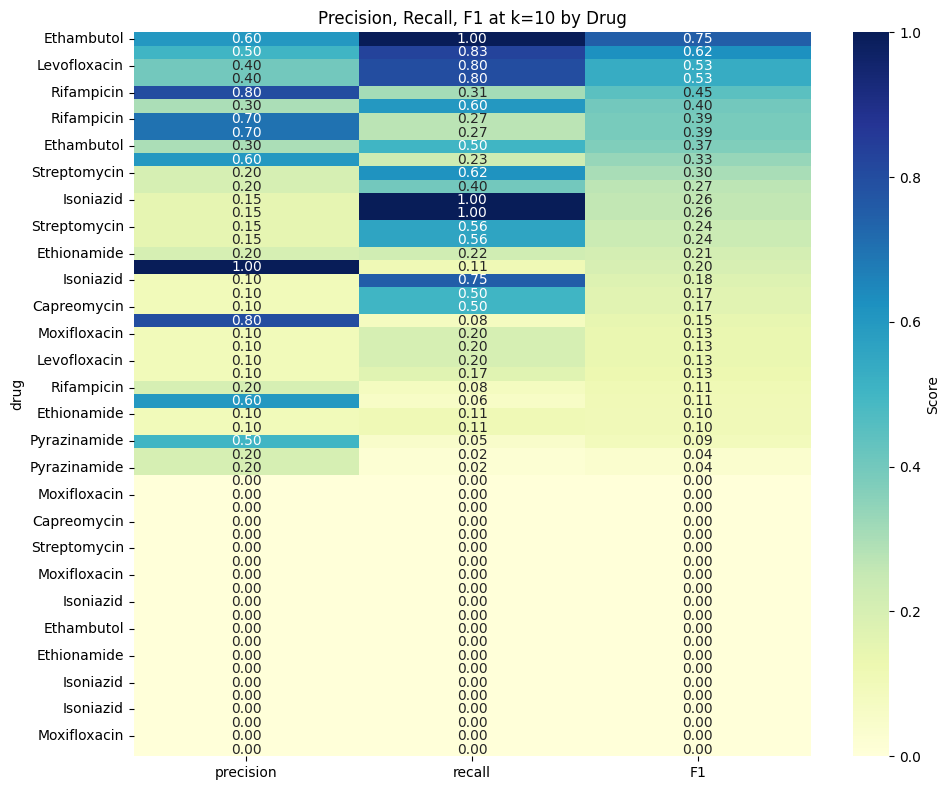

In [19]:
# Filter metrics at k=50
subset = combined_df[combined_df["k"] == 10].copy()
subset = subset[["drug", "precision", "recall", "F1"]].set_index("drug")

# Optional: sort by F1
subset = subset.sort_values("F1", ascending=False)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(subset, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={"label": "Score"})
plt.title("Precision, Recall, F1 at k=10 by Drug")
plt.tight_layout()
plt.show()


In [23]:
# import pandas as pd
# import numpy as np
# from pathlib import Path

# # -------------------------------
# # Setup
# # -------------------------------
# GENE_TO_DRUG = {
#     "katG": "INH",
#     "inhA": "INH",
#     "rpsL": "STR",
#     "gid": "STR",
#     "gyrA": "FLQ",
#     "gyrB": "FLQ",
# }

# allowed_confidences = ['1) Assoc w R', '2) Assoc w R - Interim']
# importance_dir = Path("residue_importance/esm_classical")
# catalog_path = Path("./data/filtered_variants_output.csv")
# output_path = Path("residue_importance/esm_rf_overlap_summary_druglevel.csv")

# # K thresholds
# percentiles = [10]

# # -------------------------------
# # Load WHO catalog
# # -------------------------------
# catalog_df = pd.read_csv(catalog_path)
# catalog_df = catalog_df[
#     (catalog_df["confidence"].isin(allowed_confidences)) &
#     (catalog_df["intersectional"] == True)
# ].copy()
# catalog_df["aa_pos_0idx"] = catalog_df["aa_pos"].astype(int) - 1

# # -------------------------------
# # Group genes by drug
# # -------------------------------
# from collections import defaultdict
# drug_to_genes = defaultdict(list)
# for gene, drug in GENE_TO_DRUG.items():
#     drug_to_genes[drug].append(gene)

# # -------------------------------
# # Precision-Recall Helper
# # -------------------------------
# def compute_precision_recall(true_positions, predicted_positions):
#     tp = len(true_positions.intersection(predicted_positions))
#     precision = tp / len(predicted_positions) if predicted_positions else 0
#     recall = tp / len(true_positions) if true_positions else 0
#     f1 = 2 * precision * recall / (precision + recall + 1e-8)
#     return tp, precision, recall, f1

# # -------------------------------
# # Evaluation loop (per drug)
# # -------------------------------
# all_rows = []

# for drug, genes in drug_to_genes.items():
#     print(f"Evaluating {drug}: genes={genes}")

#     # Merge all importance scores across genes
#     importance_rows = []

#     for gene in genes:
#         csv_path = importance_dir / f"{gene}_global_residue_importance_all_chunks.csv"
#         if not csv_path.exists():
#             print(f"Warning: Missing file for {gene}, skipping.")
#             continue

#         imp_df = pd.read_csv(csv_path)
#         imp_df["Gene"] = gene
#         importance_rows.append(imp_df)

#     if not importance_rows:
#         continue

#     merged_importance = pd.concat(importance_rows, ignore_index=True)

#     # Merge WHO variants for all genes
#     who_gene_df = catalog_df[catalog_df["gene"].str.lower().isin([g.lower() for g in genes])]
#     true_positions = set(zip(who_gene_df["gene"], who_gene_df["aa_pos_0idx"]))

#     total_actual_positives = len(true_positions)

#     # Create (gene, residue_position) tuples to track across genes
#     merged_importance["key"] = list(zip(merged_importance["Gene"], merged_importance["Residue_Position"]))

#     for k in percentiles:
#         top_k_count = int(np.ceil(len(merged_importance) * (k / 100)))
#         top_k_df = merged_importance.nlargest(top_k_count, "Importance")
#         predicted_positions = set(top_k_df["key"])

#         tp, precision, recall, f1 = compute_precision_recall(true_positions, predicted_positions)

#         identified_variants = who_gene_df[
#             who_gene_df[["gene", "aa_pos_0idx"]].apply(tuple, axis=1).isin(predicted_positions)
#         ]["variant"].tolist()

#         all_rows.append({
#             "Drug": drug,
#             "Genes": ",".join(genes),
#             "Total_Resistance_Positions": total_actual_positives,
#             "Top_Percentile": k,
#             "True_Positives": tp,
#             "Precision": precision,
#             "Recall": recall,
#             "F1_Score": f1,
#             "Identified_Variants": ", ".join(identified_variants) if identified_variants else "None"
#         })

# # -------------------------------
# # Save Results
# # -------------------------------
# results_df = pd.DataFrame(all_rows)
# results_df.to_csv(output_path, index=False)
# print(f"Saved drug-level PR summary to {output_path}")

In [24]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict

# -------------------------------
# Setup
# -------------------------------
GENE_TO_DRUG = {
    "katG": "INH",
    "inhA": "INH",
    "rpsL": "STR",
    "gid": "STR",
    "gyrA": "FLQ",
    "gyrB": "FLQ",
}

allowed_confidences = ['1) Assoc w R', '2) Assoc w R - Interim']
importance_dir = Path("residue_importance/esm_classical")  # Change as needed
catalog_path = Path("./data/filtered_variants_output.csv")
output_path = Path("residue_importance/esm_rf_overlap_summary_druglevel_k10.csv")

TOP_K = 10  # fixed number of top residues

# -------------------------------
# Load WHO catalog
# -------------------------------
catalog_df = pd.read_csv(catalog_path)
catalog_df = catalog_df[
    (catalog_df["confidence"].isin(allowed_confidences)) &
    (catalog_df["intersectional"] == True)
].copy()
catalog_df["aa_pos_0idx"] = catalog_df["aa_pos"].astype(int) - 1

# -------------------------------
# Group genes by drug
# -------------------------------
drug_to_genes = defaultdict(list)
for gene, drug in GENE_TO_DRUG.items():
    drug_to_genes[drug].append(gene)

# -------------------------------
# Precision-Recall Helper
# -------------------------------
def compute_precision_recall(true_positions, predicted_positions):
    tp = len(true_positions.intersection(predicted_positions))
    precision = tp / len(predicted_positions) if predicted_positions else 0
    recall = tp / len(true_positions) if true_positions else 0
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    return tp, precision, recall, f1

# -------------------------------
# Evaluation loop (per drug)
# -------------------------------
all_rows = []

for drug, genes in drug_to_genes.items():
    print(f"Evaluating {drug}: genes={genes}")

    importance_rows = []
    for gene in genes:
        csv_path = importance_dir / f"{gene}_global_residue_importance_all_chunks.csv"
        if not csv_path.exists():
            print(f"Warning: Missing file for {gene}, skipping.")
            continue

        imp_df = pd.read_csv(csv_path)
        imp_df["Gene"] = gene
        importance_rows.append(imp_df)

    if not importance_rows:
        continue

    merged_importance = pd.concat(importance_rows, ignore_index=True)
    merged_importance["key"] = list(zip(merged_importance["Gene"], merged_importance["Residue_Position"]))

    # Get true variants from WHO catalog
    who_gene_df = catalog_df[catalog_df["gene"].str.lower().isin([g.lower() for g in genes])]
    true_positions = set(zip(who_gene_df["gene"], who_gene_df["aa_pos_0idx"]))
    total_actual_positives = len(true_positions)

    # Top-k selection
    top_k_df = merged_importance.nlargest(TOP_K, "Importance")
    predicted_positions = set(top_k_df["key"])

    tp, precision, recall, f1 = compute_precision_recall(true_positions, predicted_positions)
    identified_variants = who_gene_df[
        who_gene_df[["gene", "aa_pos_0idx"]].apply(tuple, axis=1).isin(predicted_positions)
    ]["variant"].tolist()

    all_rows.append({
        "Drug": drug,
        "Genes": ",".join(genes),
        "Total_Resistance_Positions": total_actual_positives,
        "Top_K": TOP_K,
        "True_Positives": tp,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "Identified_Variants": ", ".join(identified_variants) if identified_variants else "None"
    })

# -------------------------------
# Save Results
# -------------------------------
results_df = pd.DataFrame(all_rows)
results_df.to_csv(output_path, index=False)
print(f"Saved drug-level PR summary to {output_path}")


Evaluating INH: genes=['katG', 'inhA']
Evaluating STR: genes=['rpsL', 'gid']
Evaluating FLQ: genes=['gyrA', 'gyrB']
Saved drug-level PR summary to residue_importance/esm_rf_overlap_summary_druglevel_k10.csv


In [29]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict

# -------------------------------
# Setup
# -------------------------------
GENE_TO_DRUG = {
    "katG": "INH",
    "inhA": "INH",
    "rpsL": "STR",
    "gid": "STR"
}

MODEL_DIRS = {
    "esm_rf": Path("residue_importance/esm_classical"),
    "cnn": Path("residue_importance/cnn"),
    "transformer": Path("residue_importance/transformer")
}

allowed_confidences = ['1) Assoc w R', '2) Assoc w R - Interim']
catalog_path = Path("./data/filtered_variants_output.csv")
TOP_K = 10

# -------------------------------
# Load WHO catalog
# -------------------------------
catalog_df = pd.read_csv(catalog_path)
catalog_df = catalog_df[
    (catalog_df["confidence"].isin(allowed_confidences)) & (catalog_df["intersectional"] == True)
].copy()
catalog_df["aa_pos_0idx"] = catalog_df["aa_pos"].astype(int) - 1

# -------------------------------
# Group genes by drug
# -------------------------------
drug_to_genes = defaultdict(list)
for gene, drug in GENE_TO_DRUG.items():
    drug_to_genes[drug].append(gene)

# -------------------------------
# Precision-Recall Helper
# -------------------------------
def compute_precision_recall(true_positions, predicted_positions):
    tp = len(true_positions.intersection(predicted_positions))
    precision = tp / len(predicted_positions) if predicted_positions else 0
    recall = tp / len(true_positions) if true_positions else 0
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    return tp, precision, recall, f1

# -------------------------------
# Main Loop over Model Types
# -------------------------------
for model_name, importance_dir in MODEL_DIRS.items():
    print(f"\n--- Evaluating {model_name} ---")
    all_rows = []

    for drug, genes in drug_to_genes.items():
        print(f"Drug: {drug} | Genes: {genes}")
        importance_rows = []

        for gene in genes:
            csv_path = importance_dir / f"{gene}_global_residue_importance_all_chunks.csv"
            if not csv_path.exists():
                print(f"Warning: Missing {csv_path}, skipping.")
                continue

            imp_df = pd.read_csv(csv_path)
            imp_df["Gene"] = gene
            importance_rows.append(imp_df)

        if not importance_rows:
            continue

        merged_importance = pd.concat(importance_rows, ignore_index=True)
        merged_importance["key"] = list(zip(merged_importance["Gene"], merged_importance["Residue_Position"]))

        who_gene_df = catalog_df[catalog_df["gene"].str.lower().isin([g.lower() for g in genes])]
        true_positions = set(zip(who_gene_df["gene"], who_gene_df["aa_pos_0idx"]))
        total_actual_positives = len(true_positions)

        top_k_df = merged_importance.nlargest(TOP_K, "Importance")
        predicted_positions = set(top_k_df["key"])

        tp, precision, recall, f1 = compute_precision_recall(true_positions, predicted_positions)
        identified_variants = who_gene_df[
            who_gene_df[["gene", "aa_pos_0idx"]].apply(tuple, axis=1).isin(predicted_positions)
        ]["variant"].tolist()

        all_rows.append({
            "Model": model_name,
            "Drug": drug,
            "Genes": ",".join(genes),
            "Total_Resistance_Positions": total_actual_positives,
            "Top_K": TOP_K,
            "True_Positives": tp,
            "Precision": precision,
            "Recall": recall,
            "F1_Score": f1,
            "Identified_Variants": ", ".join(identified_variants) if identified_variants else "None"
        })

    # Save output
    output_path = Path(f"residue_importance/{model_name}_multidrugs_k10.csv")
    pd.DataFrame(all_rows).to_csv(output_path, index=False)
    print(f"Saved to {output_path}")



--- Evaluating esm_rf ---
Drug: INH | Genes: ['katG', 'inhA']
Drug: STR | Genes: ['rpsL', 'gid']
Saved to residue_importance/esm_rf_multidrugs_k10.csv

--- Evaluating cnn ---
Drug: INH | Genes: ['katG', 'inhA']
Drug: STR | Genes: ['rpsL', 'gid']
Saved to residue_importance/cnn_multidrugs_k10.csv

--- Evaluating transformer ---
Drug: INH | Genes: ['katG', 'inhA']
Drug: STR | Genes: ['rpsL', 'gid']
Saved to residue_importance/transformer_multidrugs_k10.csv


In [34]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# -------------------------------
# Setup
# -------------------------------
GENE_TO_DRUG = {
    "katG": "INH",
    "inhA": "INH",
    "rpsL": "STR",
    "gid": "STR",
    "gyrA": "FLQ",
    "gyrB": "FLQ",
}

ALLOWED_CONFIDENCES = ['1) Assoc w R', '2) Assoc w R - Interim']
CATALOG_PATH = Path("./data/filtered_variants_output.csv")
FEATURE_DIR = Path("./data/feature_matrix_labels")
OUTPUT_DIR = Path("residue_importance")
TOP_K = 10

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------
# Load WHO Catalog
# -------------------------------
catalog_df = pd.read_csv(CATALOG_PATH)
catalog_df = catalog_df[
    (catalog_df["confidence"].isin(ALLOWED_CONFIDENCES)) &
    (catalog_df["intersectional"] == True)
].copy()
catalog_df["aa_pos_0idx"] = catalog_df["aa_pos"].astype(int) - 1

# -------------------------------
# Load and Concatenate Features
# -------------------------------
def load_and_concat_features(genes):
    X_list, y_list, gene_pos_map = [], [], []

    min_len = float('inf')
    for gene in genes:
        X = np.load(FEATURE_DIR / f"{gene}_feature_matrix.npy")
        y = np.load(FEATURE_DIR / f"{gene}_labels.npy", allow_pickle=True)
        min_len = min(min_len, len(X))
        X_list.append(X)
        y_list.append(y)

    # Truncate all matrices to match the shortest
    X_list = [x[:min_len] for x in X_list]
    y_list = [y[:min_len] for y in y_list]

    for i, gene in enumerate(genes):
        gene_pos_map.extend([(gene, j) for j in range(X_list[i].shape[1])])

    X_cat = np.concatenate(X_list, axis=1)
    y_cat = y_list[0]  # assumes labels are aligned after truncation
    return X_cat, y_cat, gene_pos_map

# -------------------------------
# Compute Importance Scores
# -------------------------------
def compute_residue_scores_from_coef(coef, gene_pos_map):
    return {(gene, pos): abs(score) for (gene, pos), score in zip(gene_pos_map, coef)}

# -------------------------------
# Precision-Recall Evaluation
# -------------------------------
def compute_precision_recall(true_positions, predicted_positions):
    tp = len(true_positions.intersection(predicted_positions))
    precision = tp / len(predicted_positions) if predicted_positions else 0
    recall = tp / len(true_positions) if true_positions else 0
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    return tp, precision, recall, f1

# -------------------------------
# Run Multi-Gene Ref-Alt Model
# -------------------------------
all_rows = []
drug_to_genes = defaultdict(list)
for gene, drug in GENE_TO_DRUG.items():
    drug_to_genes[drug].append(gene)

for drug, genes in drug_to_genes.items():
    print(f"\nRunning ref-alt Lasso for {drug}: {genes}")

    X, y, gene_pos_map = load_and_concat_features(genes)
    y_encoded = LabelEncoder().fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
    )

    model = LassoCV(max_iter=10000, cv=5, alphas=[0.001, 0.01, 0.1, 1, 10], random_state=42)
    model.fit(X_train, y_train)

    print("auc", roc_auc_score(y_test,model.predict(X_test)))
    coef_scores = compute_residue_scores_from_coef(model.coef_, gene_pos_map)
    imp_df = pd.DataFrame([
        {"Gene": g, "Residue_Position": p, "Importance": s} for (g, p), s in coef_scores.items()
    ])
    imp_df["key"] = list(zip(imp_df["Gene"], imp_df["Residue_Position"]))

    who_gene_df = catalog_df[catalog_df["gene"].str.lower().isin([g.lower() for g in genes])]
    true_positions = set(zip(who_gene_df["gene"], who_gene_df["aa_pos_0idx"]))
    total_actual_positives = len(true_positions)

    top_k_df = imp_df.nlargest(TOP_K, "Importance")
    predicted_positions = set(top_k_df["key"])

    tp, precision, recall, f1 = compute_precision_recall(true_positions, predicted_positions)
    identified_variants = who_gene_df[
        who_gene_df[["gene", "aa_pos_0idx"]].apply(tuple, axis=1).isin(predicted_positions)
    ]["variant"].tolist()

    all_rows.append({
        "Drug": drug,
        "Genes": ",".join(genes),
        "Model": "refalt_lasso",
        "Top_K": TOP_K,
        "Total_Resistance_Positions": total_actual_positives,
        "True_Positives": tp,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "Identified_Variants": ", ".join(identified_variants) if identified_variants else "None"
    })

# -------------------------------
# Save Final Results
# -------------------------------
out_df = pd.DataFrame(all_rows)
out_df.to_csv(OUTPUT_DIR / "refalt_multidrug_k10.csv", index=False)
print(f"Saved summary to {OUTPUT_DIR / 'refalt_multidrug_k10_summary.csv'}")



Running ref-alt Lasso for INH: ['katG', 'inhA']
auc 0.8785363283389799

Running ref-alt Lasso for STR: ['rpsL', 'gid']
auc 0.7667345525076199

Running ref-alt Lasso for FLQ: ['gyrA', 'gyrB']
auc 1.0
Saved summary to residue_importance/refalt_multidrug_k10_summary.csv


## AUC

In [ ]:
# Define the directory containing the CSV files
directory_path = "./gene_results" 

# Load all *_model_performance.csv files
all_files = glob.glob(os.path.join(directory_path, "*_token_model_performance.csv"))

# Check if any files were found
if not all_files:
    raise FileNotFoundError("No model_performance.csv files found in the specified directory.")

# Read each file and store valid dataframes
df_list = []
for file in all_files:
    try:
        df_temp = pd.read_csv(file)
        df_temp["Gene"] = os.path.basename(file).split("_")[0]  # Extract gene name from filename
        df_list.append(df_temp)
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Ensure we have valid data
if not df_list:
    raise ValueError("No valid, non-empty CSV files were found.")

# Concatenate all dataframes into a single dataframe
df = pd.concat(df_list, ignore_index=True)

# Ensure column names are correctly formatted
df.columns = df.columns.str.strip()

# Plotting
plt.figure(figsize=(12, 6))

# Using different colors for each gene
genes = df["Gene"].unique()
colors = plt.get_cmap("tab10")  # Define colormap

for i, gene in enumerate(genes):
    subset = df[df["Gene"] == gene]
    plt.barh(subset["Best Model"], subset["AUC"], label=gene, color=colors(i / len(genes)), alpha=0.7)

plt.xlabel("Spearman Correlation")
plt.ylabel("Best Model")
plt.title("Model Performance for Different Genes")
plt.xlim(0, 1)
plt.legend(title="Gene", loc="lower right")
plt.gca().invert_yaxis()

# Show the plot
plt.show()


In [ ]:
# Clean column names
df.columns = df.columns.str.strip()

# Simplify model names
def simplify_model_name(full_model_name):
    if "KNeighborsRegressor" in full_model_name:
        return "KNN"
    elif "SVR" in full_model_name:
        return "SVR"
    elif "RandomForestRegressor" in full_model_name:
        return "Random Forest"
    else:
        return "Other"

df["Model Type"] = df["Best Model"].apply(simplify_model_name)

# Filter desired models
df_filtered = df[df["Model Type"].isin(["KNN", "SVR", "Random Forest"])].copy()

# Group and compute mean AUC and standard deviation
df_grouped = df_filtered.groupby(["Gene", "Model Type"]).agg(
    AUC=("AUC", "mean"),
    Error=("AUC", "std")
).reset_index()

# Sort genes by average AUC across models
avg_auc_per_gene = df_grouped.groupby("Gene")["AUC"].mean().sort_values(ascending=False)
gene_order = avg_auc_per_gene.index.tolist()
df_grouped["Gene"] = pd.Categorical(df_grouped["Gene"], categories=gene_order, ordered=True)
df_grouped.sort_values("Gene", inplace=True)

# Assign x positions
df_grouped["Gene X"] = df_grouped["Gene"].cat.codes + 1

# Plot
plt.figure(figsize=(14, 7))
colors = {"KNN": "blue", "SVR": "orange", "Random Forest": "green"}

for model in ["KNN", "SVR", "Random Forest"]:
    subset = df_grouped[df_grouped["Model Type"] == model]
    plt.errorbar(
        subset["Gene X"], subset["AUC"],
        yerr=subset["Error"], fmt="o", label=model,
        color=colors[model], capsize=4, markersize=6
    )

plt.axhline(y=0.5, color="red", linestyle="dashed")
plt.xticks(df_grouped["Gene X"].unique(), gene_order, rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("Genes", fontsize=12)
plt.ylabel("AUC", fontsize=12)
plt.title("Model Performance for Each Gene: ESM Supervised Variant Prediction Task", fontsize=14)
plt.legend(title="Model Type", loc="lower left", fontsize=10)
plt.ylim(0.0, 1)
plt.tight_layout()
plt.show()


In [ ]:
# Load your AUC summary DataFrame (already available)
df.columns = df.columns.str.strip()  # Clean headers

# Simplify model names
def simplify_model_name(full_model_name):
    if "KNeighborsRegressor" in full_model_name:
        return "KNN"
    elif "SVR" in full_model_name:
        return "SVR"
    elif "RandomForestRegressor" in full_model_name:
        return "Random Forest"
    return "Other"

df["Model Type"] = df["Best Model"].apply(simplify_model_name)

# Group stats
df_grouped = df.groupby(["Gene", "Model Type"]).agg(
    AUC=("AUC", "mean"),
    Error=("AUC", "std")
).reset_index()

# Compute per-gene average AUC for sorting
gene_avg_auc = df_grouped.groupby("Gene")["AUC"].mean().sort_values(ascending=False)
gene_order = gene_avg_auc.index.tolist()


In [ ]:
df.to_csv("all_genes_esm_classical_model.csv", index=False)

### load data from esm + classical, ref_alt-reg, raw_seq -cnn transformer

In [ ]:
gene_list = ['rpoB','rpsL','tlyA','pncA','eis','gid','katG','inhA','embA','embB','embC','gyrB','gyrA','ethA','ethR']

In [ ]:

# Load the regression-based classical ML results
regression_df = pd.read_csv("all_genes_regression_models_performance.csv")
regression_df["model_type"] = "ref_alt"
regression_df["source"] = "regression"
regression_df = regression_df[["gene", "model", "auc", "model_type", "source"]]

# Load the ESM + classical ML results
esm_df = pd.read_csv("all_genes_esm_classical_model.csv")
esm_df = esm_df.rename(columns={"Gene": "gene", "AUC": "auc", "Model Type": "model"})
esm_df["model_type"] = "esm_classical"
esm_df["source"] = "esm"
esm_df = esm_df[["gene", "model", "auc", "model_type", "source"]]


In [ ]:
# Load the CNN results
cnn_df = pd.read_csv("cnn_results/summary_auc_scores.csv")
cnn_df = cnn_df.rename(columns={"Gene": "gene", "AUC": "auc"})
cnn_df["model"] = "cnn"
cnn_df["source"] = "raw_seq"
cnn_df["model_type"] = "raw_dl"
cnn_df = cnn_df[["gene", "model", "auc", "model_type", "source"]]

In [ ]:
# Load the Transformer results
transformer_df = pd.read_csv("transformer_results/combined_rawseq_transformer_auc.csv")
transformer_df["source"] = "raw_seq"
transformer_df = transformer_df[["gene", "model", "auc", "model_type", "source"]]

In [ ]:
# Combine all dataframes
combined_df = pd.concat([regression_df, esm_df, cnn_df, transformer_df], ignore_index=True)

In [ ]:
# Save to a single CSV
combined_df.to_csv("all_model_auc_results_combined.csv", index=False)

In [ ]:
#combined lineplot of all genes
plt.figure(figsize=(12, 6))
colors = {"KNN": "blue", "SVR": "orange", "Random Forest": "green"}

# Sort by gene performance
df_grouped["Gene"] = pd.Categorical(df_grouped["Gene"], categories=gene_order, ordered=True)
df_grouped = df_grouped.sort_values("Gene")

for model in colors:
    subset = df_grouped[df_grouped["Model Type"] == model]
    plt.errorbar(subset["Gene"], subset["AUC"], yerr=subset["Error"],
                 fmt="o-", label=model, color=colors[model], capsize=3)

plt.axhline(0.5, color="red", linestyle="dashed")
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.ylabel("AUC", fontsize=12)
plt.xlabel("Gene", fontsize=12)
plt.title("Model Performance by Gene (AUC)", fontsize=14)
plt.legend(title="Model", fontsize=10)
plt.tight_layout()
plt.show()


In [ ]:
#barplot per gene
genes_to_plot = ["rpoB", "pncA", "katG"]
subset = df_grouped[df_grouped["Gene"].isin(genes_to_plot)]

plt.figure(figsize=(8, 5))
sns.barplot(data=subset, x="Gene", y="AUC", hue="Model Type", palette=colors, errorbar="sd")
plt.title("Per-Gene Model Performance (AUC)", fontsize=14)
plt.ylabel("AUC")
plt.xlabel("Gene")
plt.ylim(0.0, 1.0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [ ]:
#histogram
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="AUC", hue="Model Type", multiple="stack", bins=20, palette=colors)
plt.title("AUC Distribution by Model Type", fontsize=14)
plt.xlabel("AUC Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd, matplotlib.pyplot as plt, math, os

def short(m):
    return ("KNN"            if "KNeighbors"    in m else
            "SVR"            if "SVR"          in m else
            "Random Forest"  if "RandomForest" in m else "Other")

df["Model"] = df["Best Model"].apply(short)

wide = (
    df.pivot(index="Gene", columns="Model", values="AUC")
      .reindex(sorted(df["Gene"].unique()))          # alpha order
)[["KNN", "SVR", "Random Forest"]]                   # fixed column order

genes      = wide.index.tolist()
n_genes    = len(genes)
n_cols     = 4
n_rows     = math.ceil(n_genes / n_cols)

# ----------------------------------------------------------------------
# 1)  grid of mini bar‑plots  →  one PDF
# ----------------------------------------------------------------------
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(3.2*n_cols, 2.4*n_rows),
                         sharey=True)
axes = axes.flatten()

for ax, gene in zip(axes, genes):
    vals = wide.loc[gene].values
    ax.bar(wide.columns, vals,
           color=["royalblue", "orange", "forestgreen"])
    ax.axhline(0.5, ls="--", color="crimson", lw=1)
    ax.set_title(gene, fontsize=9)
    ax.set_ylim(0.3, 1.0)
    ax.tick_params(axis="x", labelrotation=60, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

for ax in axes[n_genes:]:
    ax.axis("off")

fig.tight_layout()
os.makedirs("images", exist_ok=True)       # make sure the folder exists
fig.savefig("images/auc_per_gene_grid.pdf")
plt.close(fig)

# ----------------------------------------------------------------------
# 2)  individual PNGs  →  one figure per gene
# ----------------------------------------------------------------------
for gene in genes:
    vals = wide.loc[gene].values
    fig_i, ax_i = plt.subplots(figsize=(2.5, 2.3))
    ax_i.bar(wide.columns, vals,
             color=["royalblue", "orange", "forestgreen"])
    ax_i.axhline(0.5, ls="--", color="crimson", lw=1)
    ax_i.set_ylim(0.3, 1.0)
    ax_i.set_title(gene, fontsize=10)
    ax_i.tick_params(axis="x", labelrotation=60, labelsize=8)
    ax_i.tick_params(axis="y", labelsize=8)
    fig_i.tight_layout()
    fig_i.savefig(f"images/auc_{gene}.png", dpi=300)
    plt.close(fig_i)


In [ ]:
# Plot heatmap

data = {
    "Gene": ["eis", "embB", "ethA", "ethR", "gid", "gyrA", "gyrB", "inhA", "katG", "pncA", "rpoB", "rpsL", "tlyA"],
    "KNN":  [0.513, 0.926, 0.545, 0.488, 0.765, 0.838, 0.574, 0.532, 0.898, 0.845, 0.964, 0.760, 0.509],
    "SVR":  [0.494, 0.918, 0.567, 0.512, 0.709, 0.822, 0.400, 0.523, 0.893, 0.824, 0.963, 0.760, 0.504],
    "Random Forest": [0.527, 0.934, 0.565, 0.512, 0.778, 0.857, 0.568, 0.533, 0.907, 0.852, 0.965, 0.761, 0.514],
}
df = pd.DataFrame(data)
df.set_index("Gene", inplace=True)
plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, cmap="YlGnBu", vmin=0.4, vmax=1.0, cbar_kws={"label": "AUC Score"})
plt.title("AUC Performance Heatmap (Gene × Model Type)")
plt.ylabel("Gene")
plt.tight_layout()
plt.savefig("auc_heatmap.png", dpi=300)
plt.show()

In [ ]:
## multiple gene results
raw_dl_df = pd.read_csv("results/rawseq_auc.csv")
esm_cls_df = pd.read_csv("results/esm_classical_auc.csv")
etha_inha_esm = pd.read_csv("results/ethA_inhA_esm_classical_auc.csv")
etha_inha_rawseq = pd.read_csv("results/ethA_inhA_rawseq_auc.csv")

# Normalize all datasets to common format
raw_dl_df["source"] = "raw_seq"
raw_dl_df["model_type"] = "raw_dl"
raw_dl_df.rename(columns={"gene_set": "gene", "test_auc": "auc"}, inplace=True)

esm_cls_df["source"] = "esm"
esm_cls_df["model_type"] = "esm_classical"
esm_cls_df.rename(columns={"gene_set": "gene", "test_auc": "auc"}, inplace=True)

etha_inha_esm["source"] = "esm"
etha_inha_esm["model_type"] = "esm_classical"
etha_inha_esm.rename(columns={"gene_set": "gene", "test_auc": "auc"}, inplace=True)

etha_inha_rawseq["source"] = "raw_seq"
etha_inha_rawseq["model_type"] = "raw_dl"
etha_inha_rawseq.rename(columns={"gene_set": "gene", "test_auc": "auc"}, inplace=True)

# Combine all into one
combined_df = pd.concat([raw_dl_df, esm_cls_df, etha_inha_esm, etha_inha_rawseq], ignore_index=True)

# Save to CSV
combined_df.to_csv("multiple_gene_set_model_performance.csv", index=False)




## dataset details

In [1]:
import os
import pandas as pd

In [3]:
import os
import pandas as pd

# Define the list of genes of interest
# gene_list = ['rpoB', 'rpsL', 'tlyA', 'pncA', 'eis', 'gid', 'katG', 'inhA', 
#              'embA', 'embB', 'embC', 'gyrB', 'gyrA', 'ethA', 'ethR','rrs-rrl']
gene_list = ['rrs-rrl']

# Define the directory containing the per-gene CSV files
data_dir = "data/sequence_data_csv"

# Define the columns to retain
# columns_of_interest = ["Phenotype", "Protein_Sequence", "seq_len"]
columns_of_interest = ["Phenotype", "Sequence", "seq_len"]

# Prepare a list to collect statistics
phenotype_summary = []

# Iterate through each file in the directory
for file_name in os.listdir(data_dir):
    if file_name.endswith("_combined_sequence_data.csv"):
        gene_name = file_name.split("_")[0]
        if gene_name not in gene_list:
            continue
        
        file_path = os.path.join(data_dir, file_name)
        df = pd.read_csv(file_path, usecols=columns_of_interest)
        df = df[df["Phenotype"].isin(["R", "S"])]  # Filter to R/S only

        resistant_count = (df["Phenotype"] == "R").sum()
        susceptible_count = (df["Phenotype"] == "S").sum()
        total = resistant_count + susceptible_count
        resistance_rate = resistant_count / total if total > 0 else 0

        # Calculate the average sequence length
        max_seq_len = df["seq_len"].max() if not df["seq_len"].empty else 0

        phenotype_summary.append({
            "Gene": gene_name,
            "Sequence Length": round(max_seq_len),
            "Resistant": resistant_count,
            "Susceptible": susceptible_count,
            "Total": total,
            "Resistance Rate": round(resistance_rate, 3)
        })




In [4]:
phenotype_summary

[{'Gene': 'rrs-rrl',
  'Sequence Length': 3138,
  'Resistant': 474,
  'Susceptible': 2721,
  'Total': 3195,
  'Resistance Rate': 0.148}]

In [10]:
# Convert to DataFrame
phenotype_summary_df = pd.DataFrame(phenotype_summary).sort_values(by="Total", ascending=False)

In [11]:
phenotype_summary_df

,Gene,Sequence Length,Resistant,Susceptible,Total,Resistance Rate
12,rpoB,3519,3533,11881,15414,0.229
9,inhA,810,4322,10844,15166,0.285
10,katG,2223,4322,10844,15166,0.285
1,embA,3285,1838,10116,11954,0.154
2,embB,3297,1838,10116,11954,0.154
3,embC,3285,1838,10116,11954,0.154
11,pncA,561,1358,9095,10453,0.130
6,gid,675,2018,4524,6542,0.308
13,rpsL,375,2018,4524,6542,0.308
14,tlyA,806,484,3091,3575,0.135


In [2]:
import pandas as pd
who_catalog=pd.read_csv("data/filtered_variants_output.csv")
who_catalog.columns

Index(['drug', 'gene', 'variant', 'effect', 'Present_R', 'Present_S',
       'confidence', 'one_letter_mutation', 'aa_pos', 'aa_change', 'aa_ref',
       'intersectional'],
      dtype='object')

In [3]:
import numpy as np
np.unique(who_catalog['confidence'])

array(['1) Assoc w R', '2) Assoc w R - Interim',
       '3) Uncertain significance', '4) Not assoc w R - Interim',
       '5) Not assoc w R'], dtype=object)

In [4]:
# Map confidence labels
confidence_map = {
    "1) Assoc w R": "R-associated",
    "2) Assoc w R - Interim": "R-associated",
    "3) Uncertain significance": "Uncertain",
    "4) Not assoc w R - Interim": "Not associated",
    "5) Not assoc w R": "Not associated"
}
who_catalog["confidence_class"] = who_catalog["confidence"].map(confidence_map)

# Count per gene
summary = who_catalog.groupby("gene").agg(
    Total_Variants=("variant", "count"),
    Assoc_w_R=("confidence_class", lambda x: (x == "R-associated").sum()),
    Not_or_Uncertain=("confidence_class", lambda x: (x != "R-associated").sum()),
    Intersectional=("intersectional", "sum")
).reset_index()

summary = summary.sort_values("Total_Variants", ascending=False)
summary


,gene,Total_Variants,Assoc_w_R,Not_or_Uncertain,Intersectional
10,katG,841,5,836,839
12,rpoB,795,103,692,795
2,embB,784,13,771,784
1,embA,678,0,678,678
4,ethA,567,9,558,567
3,embC,550,0,550,550
6,gid,511,9,502,510
7,gyrA,466,10,456,464
11,pncA,367,206,161,364
8,gyrB,319,8,311,319


In [24]:
def highlight_diff(seq1, seq2, window=10):
    """Highlight the first difference between two sequences."""
    for i, (a, b) in enumerate(zip(seq1, seq2)):
        if a != b:
            start = max(i - window, 0)
            end = i + window + 1
            return (
                seq1[start:i] + "[" + a + "]" + seq1[i+1:end],
                seq2[start:i] + "[" + b + "]" + seq2[i+1:end],
                i
            )
    return (seq1[:2*window+1], seq2[:2*window+1], -1)

# Load a sample gene file
gene_file = "data/sequence_data_csv/rpoB_combined_sequence_data.csv"
df = pd.read_csv(gene_file)

# Keep only columns of interest
df = df[["Filename", "Sequence", "Phenotype", "Protein_Sequence", "Frameshift_Mutation"]]

# Filter R and S separately
df_R = df[df["Phenotype"] == "R"]
df_S = df[df["Phenotype"] == "S"]

# Select representative rows
example_rows = []

# 1. One S example (reference)
ref_row = df_S.drop_duplicates(subset=["Sequence", "Protein_Sequence"]).iloc[0]
example_rows.append(ref_row)

# 2. Synonymous R (DNA changes, protein same)
synonymous_R = df_R[df_R["Protein_Sequence"] == ref_row["Protein_Sequence"]]
if not synonymous_R.empty:
    syn_row = synonymous_R.iloc[0]
    example_rows.append(syn_row)

# 3. Non-synonymous R (DNA + protein changes)
nonsyn_R = df_R[df_R["Protein_Sequence"] != ref_row["Protein_Sequence"]]
if not nonsyn_R.empty:
    nonsyn_row = nonsyn_R.iloc[0]
    example_rows.append(nonsyn_row)

# 4. Optional: One frameshift mutation example
frameshift = df[df["Frameshift_Mutation"] != 0]
if not frameshift.empty:
    fs_row = frameshift.iloc[0]
    example_rows.append(fs_row)

# Generate highlighted sequences
highlighted_rows = []
for row in example_rows:
    dna_hl, _, _ = highlight_diff(ref_row["Sequence"], row["Sequence"])
    protein_hl, _, _ = highlight_diff(ref_row["Protein_Sequence"], row["Protein_Sequence"])
    
    highlighted_rows.append({
        "Filename": row["Filename"],
        "Phenotype": row["Phenotype"],
        "DNA (highlighted)": dna_hl,
        "Protein (highlighted)": protein_hl,
        "Frameshift": row["Frameshift_Mutation"]
    })



In [25]:
# Convert to DataFrame
highlighted_df = pd.DataFrame(highlighted_rows)
highlighted_df

,Filename,Phenotype,DNA (highlighted),Protein (highlighted),Frameshift
0,SAMEA1530971,S,TTGGCAGATTCCCGCCAGAGC,LADSRQSKTAASPSPSRPQSS,0
1,SAMN08214865,R,TTGGCAGATTCCCGCCAGAGC,LADSRQSKTAASPSPSRPQSS,0
2,SAMEA2533928,R,CGCCGACTGT[C]GGCGCTGGGG,LSGLTHKRRL[S]ALGPGGLSRE,0


In [32]:
import pandas as pd
import os

# Re-load data after kernel reset
file_path = "/work/pi_annagreen_umass_edu/mahbuba/Data-Curation-for-MTB/protein-tasks/data/sequence_data_csv/rpoB_combined_sequence_data.csv"
example_df = pd.read_csv(file_path)

# Function to highlight first mutation inline while keeping prefixes the same
def get_highlighted_diff_anchor(ref_seq, alt_seq, window=20):
    """Highlight the first mutation while aligning start of sequence"""
    for i, (r, a) in enumerate(zip(ref_seq, alt_seq)):
        if r != a:
            start = max(0, i - 2)
            end = start + window
            highlighted_alt = (
                alt_seq[start:i] + "[" + alt_seq[i] + "]" + alt_seq[i + 1:end]
            )
            return highlighted_alt
    return alt_seq[:window]

# Assume the first row is reference (susceptible)
ref_row = example_df.iloc[0]
ref_dna = ref_row["Sequence"]
ref_protein = ref_row["Protein_Sequence"]

# Apply the highlighting
highlighted_dna = []
highlighted_protein = []

for idx, row in example_df.iterrows():
    dna = row["Sequence"]
    protein = row["Protein_Sequence"]
    highlighted_dna.append(get_highlighted_diff_anchor(ref_dna, dna))
    highlighted_protein.append(get_highlighted_diff_anchor(ref_protein, protein))

# Add to DataFrame
example_df["DNA (highlighted)"] = highlighted_dna
example_df["Protein (highlighted)"] = highlighted_protein

# Shorten to only necessary columns
final_example_df = example_df[["Filename", "Phenotype", "DNA (highlighted)", "Protein (highlighted)", "Frameshift_Mutation"]]
final_example_df.rename(columns={"Frameshift_Mutation": "Frameshift"}, inplace=True)


/tmp/ipykernel_1554400/1601120547.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_example_df.rename(columns={"Frameshift_Mutation": "Frameshift"}, inplace=True)


In [33]:
final_example_df

,Filename,Phenotype,DNA (highlighted),Protein (highlighted),Frameshift
0,SAMEA1530971,S,TTGGCAGATTCCCGCCAGAG,LADSRQSKTAASPSPSRPQS,0
1,SAMN08732466,S,TTGGCAGATTCCCGCCAGAG,LADSRQSKTAASPSPSRPQS,0
2,SAMN08629052,S,GC[C]GCCTACACCCTGCAGGA,LADSRQSKTAASPSPSRPQS,0
3,SAMEA3558278,S,TTGGCAGATTCCCGCCAGAG,LADSRQSKTAASPSPSRPQS,0
4,SAMN07659330,S,GG[G]GACAAGCTGGCCGGCCG,LADSRQSKTAASPSPSRPQS,0
...,...,...,...,...,...
15409,SAMEA1102349,R,GT[T]GGCGCTGGGGCCCGGCG,RL[L]ALGPGGLSRERAGLEVR,0
15410,SAMEA1101452,S,GG[G]GACAAGCTGGCCGGCCG,LADSRQSKTAASPSPSRPQS,0
15411,SAMEA1102309,R,GT[T]GGCGCTGGGGCCCGGCG,RL[L]ALGPGGLSRERAGLEVR,0
15412,SAMEA1102286,R,GT[T]GGCGCTGGGGCCCGGCG,RL[L]ALGPGGLSRERAGLEVR,0


In [37]:
import pandas as pd

# Load the example CSV file
file_path = "/work/pi_annagreen_umass_edu/mahbuba/Data-Curation-for-MTB/protein-tasks/data/sequence_data_csv/rpoB_combined_sequence_data.csv"
df = pd.read_csv(file_path)

# Get the sequences
seq_ref = df.loc[0, "Protein_Sequence"]
seq_var = df.loc[5, "Protein_Sequence"]

# Find the first index where the characters differ
mutation_index = next((i for i, (a, b) in enumerate(zip(seq_ref, seq_var)) if a != b), None)
print(mutation_index)

# Extract ±5 residues around the mutation
window_size = 5
start = max(0, mutation_index - window_size)
end = mutation_index + window_size + 1

ref_window = seq_ref[start:end]
var_window = seq_var[start:end]

mutation_index, ref_window, var_window


449


(449, 'HKRRLSALGPG', 'HKRRLLALGPG')

In [40]:
# Print both rows (reference and variant)
rows_of_interest = df.loc[[0, 5], ["Filename", "Phenotype", "Protein_Sequence"]].copy()

# Add columns for mutation window
rows_of_interest["Mutation_Window"] = [ref_window, var_window]
rows_of_interest["Mutation_Position"] = mutation_index

# Truncate the full protein sequence for clarity
rows_of_interest["Protein_Sequence"] = rows_of_interest["Protein_Sequence"].str.slice(0, 30) + "..."

print(rows_of_interest)


       Filename Phenotype                   Protein_Sequence Mutation_Window  \
0  SAMEA1530971         S  LADSRQSKTAASPSPSRPQSSSNNSVPGAP...     HKRRLSALGPG   
5  SAMEA2533928         R  LADSRQSKTAASPSPSRPQSSSNNSVPGAP...     HKRRLLALGPG   

   Mutation_Position  
0                449  
5                449  


In [41]:
import pandas as pd

# Load the data
file_path = "/work/pi_annagreen_umass_edu/mahbuba/Data-Curation-for-MTB/protein-tasks/data/sequence_data_csv/rpoB_combined_sequence_data.csv"
df = pd.read_csv(file_path)

# Reference sequence (S)
seq_ref = df.loc[0, "Protein_Sequence"]

# Mutation index
mutation_index = next((i for i, (a, b) in enumerate(zip(seq_ref, df.loc[5, "Protein_Sequence"])) if a != b), None)

# Extract window
window_size = 5
start = max(0, mutation_index - window_size)
end = mutation_index + window_size + 1
ref_window = seq_ref[start:end]

# Add a mutation window column
df["Mutation_Window"] = df["Protein_Sequence"].str.slice(start, end)

# Find rows that match the reference in the window
matching_rows = df[df["Mutation_Window"] == ref_window]

# Find rows that differ in the window
non_matching_rows = df[df["Mutation_Window"] != ref_window]

# Sample 4 from matching and 1 from non-matching
selected_rows = pd.concat([
    matching_rows.sample(n=4, random_state=42),
    non_matching_rows.sample(n=1, random_state=42)
]).copy()

# Add mutation index and truncate protein for display
selected_rows["Mutation_Position"] = mutation_index
selected_rows["Protein_Sequence"] = selected_rows["Protein_Sequence"].str.slice(0, 30) + "..."

# Reorder columns for clarity
selected_rows = selected_rows[["Filename", "Phenotype", "Protein_Sequence", "Mutation_Window", "Mutation_Position"]]

selected_rows = selected_rows.reset_index(drop=True)



In [42]:
selected_rows

,Filename,Phenotype,Protein_Sequence,Mutation_Window,Mutation_Position
0,SAMN03647345,S,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449
1,SAMEA1118242,S,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449
2,SAMEA104394398,S,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449
3,SAMEA104326166,S,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449
4,SAMN02414866,R,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLLALGPG,449


In [1]:
import pandas as pd

# Load the data
file_path = "/work/pi_annagreen_umass_edu/mahbuba/Data-Curation-for-MTB/protein-tasks/data/sequence_data_csv/rpoB_combined_sequence_data.csv"
df = pd.read_csv(file_path)

# Reference sequence (S)
seq_ref = df.loc[0, "Protein_Sequence"]
dna_ref = df.loc[0, "Sequence"]

# Variant sequence (R)
seq_var = df.loc[5, "Protein_Sequence"]
dna_var = df.loc[5, "Sequence"]

# Mutation index
mutation_index = next((i for i, (a, b) in enumerate(zip(seq_ref, seq_var)) if a != b), None)

# Extract window
window_size = 5
start = max(0, mutation_index - window_size)
end = mutation_index + window_size + 1
ref_window = seq_ref[start:end]

# Add mutation window columns
df["Protein_Window"] = df["Protein_Sequence"].str.slice(start, end)

# Convert protein index to DNA range
dna_start = start * 3
dna_end = end * 3
df["DNA_Window"] = df["Sequence"].str.slice(dna_start, dna_end)

# Find rows that match the reference in the protein window
matching_rows = df[df["Protein_Window"] == ref_window]

# Find rows that differ in the protein window
non_matching_rows = df[df["Protein_Window"] != ref_window]

# Sample 4 from matching and 1 from non-matching
selected_rows = pd.concat([
    matching_rows.sample(n=4, random_state=42),
    non_matching_rows.sample(n=1, random_state=42)
]).copy()

# Add mutation index and truncate full sequences for display
selected_rows["Mutation_Position"] = mutation_index
selected_rows["Protein_Sequence"] = selected_rows["Protein_Sequence"].str.slice(0, 30) + "..."
selected_rows["Sequence"] = selected_rows["Sequence"].str.slice(0, 60) + "..."

# Reorder columns for clarity
selected_rows = selected_rows[[
    "Filename", "Phenotype", "Sequence", "DNA_Window",
    "Protein_Sequence", "Protein_Window", "Mutation_Position"
]]
selected_rows

,Filename,Phenotype,Sequence,DNA_Window,Protein_Sequence,Protein_Window,Mutation_Position
15262,SAMN03647345,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449
10455,SAMEA1118242,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449
12275,SAMEA104394398,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449
9536,SAMEA104326166,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449
740,SAMN02414866,R,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTTGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLLALGPG,449


In [2]:
def find_mutation_positions(seq_ref, seq):
    return [i for i, (a, b) in enumerate(zip(seq_ref, seq)) if a != b]

df["Mutation_Positions"] = df["Protein_Sequence"].apply(lambda seq: find_mutation_positions(seq_ref, seq))


In [3]:
df["Primary_Mutation_Position"] = df["Mutation_Positions"].apply(lambda lst: lst[0] if lst else None)


In [4]:
df

,Filename,Sequence,Phenotype,seq_len,hamming_dist,Protein_Sequence,Frameshift_Mutation,Protein_Window,DNA_Window,Mutation_Positions,Primary_Mutation_Position
0,SAMEA1530971,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,0,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,[],NaN
1,SAMN08732466,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,0,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,[],NaN
2,SAMN08629052,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,1,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,[],NaN
3,SAMEA3558278,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,0,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,[],NaN
4,SAMN07659330,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,2,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,[],NaN
...,...,...,...,...,...,...,...,...,...,...,...
15409,SAMEA1102349,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,R,3519,3,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,HKRRLLALGPG,CACAAGCGCCGACTGTTGGCGCTGGGGCCCGGC,[449],449.0
15410,SAMEA1101452,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,2,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,[],NaN
15411,SAMEA1102309,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,R,3519,4,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,HKRRLLALGPG,CACAAGCGCCGACTGTTGGCGCTGGGGCCCGGC,[449],449.0
15412,SAMEA1102286,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,R,3519,3,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,HKRRLLALGPG,CACAAGCGCCGACTGTTGGCGCTGGGGCCCGGC,[449],449.0


In [4]:
import pandas as pd

# Load the data
file_path = "/work/pi_annagreen_umass_edu/mahbuba/Data-Curation-for-MTB/protein-tasks/data/sequence_data_csv/rpoB_combined_sequence_data.csv"
df = pd.read_csv(file_path)

# Reference protein sequence
seq_ref = df.loc[0, "Protein_Sequence"]

# Compute mutation positions per row
def find_mutation_positions(seq):
    return [i for i, (a, b) in enumerate(zip(seq_ref, seq)) if a != b]

df["Mutation_Positions"] = df["Protein_Sequence"].apply(find_mutation_positions)
df["Primary_Mutation_Position"] = df["Mutation_Positions"].apply(lambda lst: lst[0] if lst else None)

# Add readable mutation label (e.g., S450L)
def get_mutation_label(seq, ref_seq, pos):
    if pd.isna(pos):  # handles None and NaN
        return None
    pos = int(pos)
    if pos >= len(seq) or pos >= len(ref_seq):
        return None
    return f"{ref_seq[pos]}{pos+1}{seq[pos]}"  # 1-based indexing

df["Mutation_Label"] = df.apply(
    lambda row: get_mutation_label(row["Protein_Sequence"], seq_ref, row["Primary_Mutation_Position"]),
    axis=1
)
# Select first row that has at least one mutation
valid_row = df[df["Primary_Mutation_Position"].notnull()].iloc[0]
mutation_index = valid_row["Primary_Mutation_Position"]
mutation_index = int(mutation_index)
# Extract window around mutation site
window_size = 5
start = max(0, mutation_index - window_size)
end = mutation_index + window_size + 1
print(start,end)
ref_window = seq_ref[start:end]

# Add window columns
df["Protein_Window"] = df["Protein_Sequence"].str.slice(start, end)
df["DNA_Window"] = df["Sequence"].str.slice(start * 3, end * 3)

# Find matching and non-matching windows
matching = df[df["Protein_Window"] == ref_window]
non_matching = df[df["Protein_Window"] != ref_window]



444 455


In [6]:
# Sample rows

selected_rows = pd.concat([
    matching.sample(n=10, random_state=42),
    non_matching.sample(n=5, random_state=42)
]).copy()


# Format for output
selected_rows["Mutation_Position"] = mutation_index
selected_rows["Protein_Sequence"] = selected_rows["Protein_Sequence"].str.slice(0, 30) + "..."
selected_rows["Sequence"] = selected_rows["Sequence"].str.slice(0, 60) + "..."

# Reorder columns (optional: add Mutation_Label for clarity)
selected_rows = selected_rows[[ 
    "Filename", "Phenotype", "Sequence", "DNA_Window",
    "Protein_Sequence", "Protein_Window", "Mutation_Position", "Mutation_Label"
]]




In [7]:
selected_rows

,Filename,Phenotype,Sequence,DNA_Window,Protein_Sequence,Protein_Window,Mutation_Position,Mutation_Label
15262,SAMN03647345,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,None
10455,SAMEA1118242,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,None
12275,SAMEA104394398,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,E1145G
9536,SAMEA104326166,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,None
5995,SAMN08913349,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,None
8445,SAMN03648762,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,None
3806,SAMEA1708212,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,None
1435,SAMEA104394594,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,None
1150,SAMN07765970,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,None
4848,SAMEA1556699,S,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,LADSRQSKTAASPSPSRPQSSSNNSVPGAP...,HKRRLSALGPG,449,None


In [8]:
# Define focal mutation positions (0-based indexing)
focal_positions = [434, 444, 449, 525]  # 1-based positions 435, 445, 450, 526

# Function to compute mutation label at a given position
def get_label_at_position(seq, ref_seq, pos):
    if pos >= len(seq) or pos >= len(ref_seq):
        return None
    if seq[pos] == ref_seq[pos]:
        return None
    return f"{ref_seq[pos]}{pos+1}{seq[pos]}"  # 1-based label

# Apply mutation label extraction for each focal position
for pos in focal_positions:
    col_name = f"Mutation_{pos+1}"  # e.g., Mutation_435
    df[col_name] = df["Protein_Sequence"].apply(lambda seq: get_label_at_position(seq, seq_ref, pos))

In [9]:
df

,Filename,Sequence,Phenotype,seq_len,hamming_dist,Protein_Sequence,Frameshift_Mutation,Mutation_Positions,Primary_Mutation_Position,Mutation_Label,Protein_Window,DNA_Window,Mutation_435,Mutation_445,Mutation_450,Mutation_526
0,SAMEA1530971,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,0,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[],NaN,None,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,None,None,None,None
1,SAMN08732466,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,0,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[],NaN,None,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,None,None,None,None
2,SAMN08629052,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,1,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[],NaN,None,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,None,None,None,None
3,SAMEA3558278,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,0,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[],NaN,None,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,None,None,None,None
4,SAMN07659330,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,2,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[],NaN,None,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15409,SAMEA1102349,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,R,3519,3,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[449],449.0,S450L,HKRRLLALGPG,CACAAGCGCCGACTGTTGGCGCTGGGGCCCGGC,None,None,S450L,None
15410,SAMEA1101452,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,2,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[],NaN,None,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,None,None,None,None
15411,SAMEA1102309,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,R,3519,4,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[449],449.0,S450L,HKRRLLALGPG,CACAAGCGCCGACTGTTGGCGCTGGGGCCCGGC,None,None,S450L,None
15412,SAMEA1102286,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,R,3519,3,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[449],449.0,S450L,HKRRLLALGPG,CACAAGCGCCGACTGTTGGCGCTGGGGCCCGGC,None,None,S450L,None


In [10]:
# Drop rows with no mutation
valid_df = df[df["Primary_Mutation_Position"].notnull()].copy()

# Round/truncate to int for grouping (in case of float NaNs or .0 values)
valid_df["Primary_Mutation_Position"] = valid_df["Primary_Mutation_Position"].astype(int)

# Drop duplicates based on mutation position — this ensures uniqueness
unique_rows = valid_df.drop_duplicates(subset="Primary_Mutation_Position", keep="first")

# Sample up to 5 unique positions (or fewer if less are available)
selected_rows = unique_rows.sample(n=min(5, len(unique_rows)), random_state=42).copy()


In [11]:
selected_rows

,Filename,Sequence,Phenotype,seq_len,hamming_dist,Protein_Sequence,Frameshift_Mutation,Mutation_Positions,Primary_Mutation_Position,Mutation_Label,Protein_Window,DNA_Window,Mutation_435,Mutation_445,Mutation_450,Mutation_526
592,SAMN02585979,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,R,3519,3,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,"[428, 434]",428,Q429H,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,D435Y,None,None,None
11380,SAMEA2533629,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,1,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[453],453,P454L,HKRRLSALGLG,CACAAGCGCCGACTGTCGGCGCTGGGGCTCGGC,None,None,None,None
6949,SAMEA3558815,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,R,3519,9,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,"[442, 443, 444, 445]",442,L443-,PQRRLSALGPG,CCCCAGCGCCGACTGTCGGCGCTGGGGCCCGGC,None,H445P,None,None
3019,SAMN08436285,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,1,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[343],343,E344Q,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,None,None,None,None
2016,SAMN03648257,TTGGCAGATTCCCGCCAGAGCAAAACAGCCGCTAGTCCTAGTCCGA...,S,3519,1,LADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLREPLEVPG...,0,[269],269,D270E,HKRRLSALGPG,CACAAGCGCCGACTGTCGGCGCTGGGGCCCGGC,None,None,None,None
